C:\Users\Hp\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['odour' 'lead(ppm)' 'pesticide_(µg/l)']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\Hp\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['Odour' 'Lead(ppm)' 'Pesticide (µg/l)']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


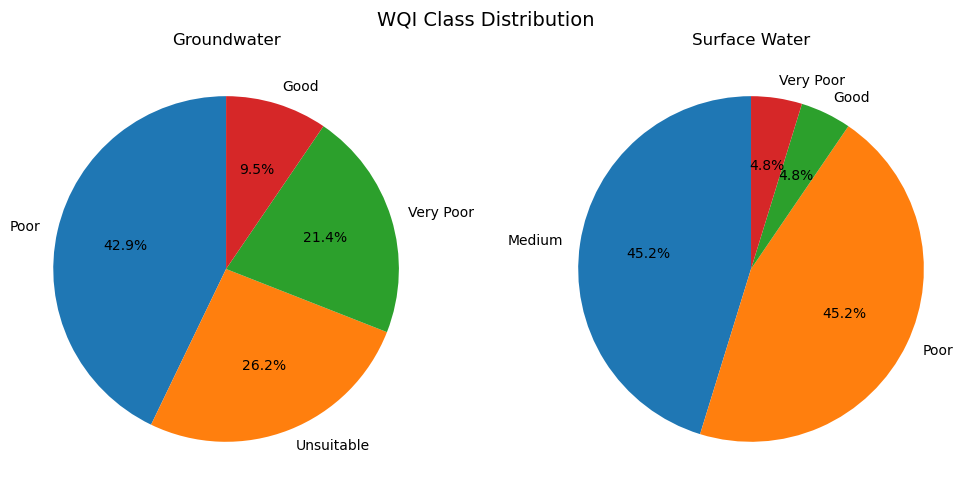

Saved: Fig_WQI_Class_Distribution_GW_SW.png
All paper figures saved in: WQI_classification_outputs\plots


In [10]:
# WQI CLASSIFICATION: PAPER FIGURES
# Run this file after the GW/SW classification notebooks.
# It reads the CSV outputs and creates compact, high-resolution PNG figures.

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize

OUT = "WQI_classification_outputs"
PLOTS = os.path.join(OUT, "plots")
os.makedirs(PLOTS, exist_ok=True)

gw = pd.read_csv("gw_wqi.csv")
sw = pd.read_csv("surface_wqi.csv")
gw_r = pd.read_csv(os.path.join(OUT, "GW_all_results.csv"))
sw_r = pd.read_csv(os.path.join(OUT, "SW_all_results.csv"))
gw_p = pd.read_csv(os.path.join(OUT, "GW_test_predictions_all_models.csv"))
sw_p = pd.read_csv(os.path.join(OUT, "SW_test_predictions_all_models.csv"))

def chi_scores(df, target, wqi, drop_iron=False):
    near = [c for c in df.columns if df[c].isna().all() or df[c].isna().sum() >= len(df)-1]
    cols = df.drop(columns=near+[wqi,target], errors="ignore").select_dtypes(include=np.number).columns
    rows = []
    for col in cols:
        if col.lower() == "year" or (drop_iron and col == "iron_(ppm)"):
            continue
        z = df[[col,target]].dropna()
        if z[col].nunique() < 2:
            continue
        z["bin"] = pd.qcut(z[col], q=min(4,z[col].nunique()), duplicates="drop")
        table = pd.crosstab(z["bin"], z[target])
        if table.shape[0] < 2 or table.shape[1] < 2:
            continue
        chi, p, dof, _ = chi2_contingency(table)
        rows.append([col, chi, p, dof, p < 0.05])
    return pd.DataFrame(rows, columns=["Feature","Chi2","p_value","df","Significant_p<0.05"]).sort_values("Chi2", ascending=False)

gw_chi = chi_scores(gw, "wqi_class", "wqi", True)
sw_chi = chi_scores(sw, "WQI_Class", "WQI", False)
gw_chi.to_csv(os.path.join(OUT,"GW_chi_square_scores.csv"),index=False)
sw_chi.to_csv(os.path.join(OUT,"SW_chi_square_scores.csv"),index=False)

# 1. Combined class distribution
fig, ax = plt.subplots(1,2,figsize=(12,5))
for a,df,target,title in [(ax[0],gw,"wqi_class","Groundwater"),(ax[1],sw,"WQI_Class","Surface Water")]:
    v=df[target].value_counts()
    bars=a.bar(v.index.astype(str),v.values)
    a.set_title(title + " WQI Class Distribution")
    a.set_ylabel("Number of samples")
    a.tick_params(axis="x",rotation=25)
    for b,n in zip(bars,v): a.text(b.get_x()+b.get_width()/2,n+0.3,str(n),ha="center")
fig.tight_layout()
fig.savefig(os.path.join(PLOTS,"Fig_Class_Distribution_Combined.png"),dpi=400,bbox_inches="tight")
plt.close(fig)

# 2. All classification bar plots + chi-square in one figure
metrics=[("Testing Accuracy","Accuracy"),("Testing Precision","Precision"),
         ("Testing Recall","Recall"),("Testing F1","F1 Score"),
         ("Testing MCC","MCC"),("5-Fold CV F1","5-Fold CV F1")]
fig,ax=plt.subplots(3,3,figsize=(16,13))
for a,(col,title) in zip(ax.flat[:6],metrics):
    x=np.arange(6); w=.36
    a.bar(x-w/2,gw_r[col],w,label="GW")
    a.bar(x+w/2,sw_r[col],w,label="SW")
    a.set_xticks(x); a.set_xticklabels(gw_r.Model,rotation=35,ha="right",fontsize=8)
    a.set_ylim(0,1.12); a.set_title(title); a.set_ylabel("Score")
    for i,v in enumerate(gw_r[col]): a.text(i-w/2,v+.015,f"{v:.2f}",ha="center",fontsize=7)
    for i,v in enumerate(sw_r[col]): a.text(i+w/2,v+.015,f"{v:.2f}",ha="center",fontsize=7)
ax[0,0].legend(fontsize=8)
for a,chi,title in [(ax[2,0],gw_chi,"GW χ² Feature Association"),(ax[2,1],sw_chi,"SW χ² Feature Association")]:
    top=chi.head(8).sort_values("Chi2")
    a.barh(top.Feature.astype(str),top.Chi2)
    a.set_title(title); a.set_xlabel("χ² statistic"); a.tick_params(axis="y",labelsize=8)
ax[2,2].axis("off")
fig.suptitle("Classification Performance and χ² Feature Association",fontsize=15)
fig.tight_layout()
fig.savefig(os.path.join(PLOTS,"Fig_Bar_Plots_Combined.png"),dpi=400,bbox_inches="tight")
plt.close(fig)

# 3. All 12 confusion matrices in one high-resolution figure
fig,ax=plt.subplots(4,3,figsize=(13,17))
for j,name in enumerate(gw_r.Model):
    r,c=divmod(j,3); a=ax[r,c]
    z=gw_p[gw_p.Model==name]
    labs=list(range(len(pd.read_csv(os.path.join(OUT,"GW_class_encoding.csv")))))
    cm=confusion_matrix(z.y_true,z.y_pred,labels=labs)
    a.imshow(cm); a.set_title("GW — "+name,fontsize=9)
    names=pd.read_csv(os.path.join(OUT,"GW_class_encoding.csv"))["WQI_Class"].tolist()
    a.set_xticks(range(len(names))); a.set_xticklabels(names,rotation=45,ha="right",fontsize=7)
    a.set_yticks(range(len(names))); a.set_yticklabels(names,fontsize=7)
    a.set_xlabel("Predicted",fontsize=8); a.set_ylabel("Actual",fontsize=8)
    for i in range(cm.shape[0]):
        for k in range(cm.shape[1]): a.text(k,i,str(cm[i,k]),ha="center",va="center",fontsize=8)
for j,name in enumerate(sw_r.Model):
    r,c=divmod(j,3); r+=2; a=ax[r,c]
    z=sw_p[sw_p.Model==name]
    names=pd.read_csv(os.path.join(OUT,"SW_class_encoding.csv"))["WQI_Class"].tolist()
    labs=list(range(len(names)))
    cm=confusion_matrix(z.y_true,z.y_pred,labels=labs)
    a.imshow(cm); a.set_title("SW — "+name,fontsize=9)
    a.set_xticks(range(len(names))); a.set_xticklabels(names,rotation=45,ha="right",fontsize=7)
    a.set_yticks(range(len(names))); a.set_yticklabels(names,fontsize=7)
    a.set_xlabel("Predicted",fontsize=8); a.set_ylabel("Actual",fontsize=8)
    for i in range(cm.shape[0]):
        for k in range(cm.shape[1]): a.text(k,i,str(cm[i,k]),ha="center",va="center",fontsize=8)
fig.suptitle("Held-Out Test Confusion Matrices — All Classifiers",fontsize=15)
fig.tight_layout()
fig.savefig(os.path.join(PLOTS,"Fig_Confusion_Matrices_All.png"),dpi=400,bbox_inches="tight")
plt.close(fig)

# 4. ROC-AUC
def make_roc(preds, title, ax):
    rows=[]
    for name in preds.Model.unique():
        z=preds[preds.Model==name]
        classes=np.array(sorted(z.y_true.unique()))
        aucs=[]
        for cls in classes:
            col="prob_"+str(cls)
            if col in z:
                yb=(z.y_true.values==cls).astype(int)
                if 0 < yb.sum() < len(yb):
                    aucs.append(roc_auc_score(yb,z[col]))
        macro=float(np.mean(aucs)) if aucs else np.nan
        rows.append([name,macro])
        yb=label_binarize(z.y_true,classes=classes)
        p=np.column_stack([z["prob_"+str(cls)] for cls in classes])
        fpr,tpr,_=roc_curve(yb.ravel(),p.ravel())
        ax.plot(fpr,tpr,label=f"{name} (AUC={macro:.2f})")
    ax.plot([0,1],[0,1],"--",linewidth=1)
    ax.set_title(title); ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
    ax.legend(fontsize=7)
    return rows

fig,ax=plt.subplots(1,2,figsize=(14,6))
roc_rows=[]
for water,preds,a,title in [("GW",gw_p,ax[0],"Groundwater"),("SW",sw_p,ax[1],"Surface Water")]:
    for n,v in make_roc(preds,title+" ROC–AUC (Held-Out Test)",a):
        roc_rows.append([water,n,v])
fig.tight_layout()
fig.savefig(os.path.join(PLOTS,"Fig_ROC_AUC_All_Models.png"),dpi=400,bbox_inches="tight")
plt.close(fig)
pd.DataFrame(roc_rows,columns=["Water Type","Model","Macro AUC"]).to_csv(os.path.join(OUT,"ROC_AUC_results.csv"),index=False)

# 5. PCA + chi-square
fig,ax=plt.subplots(2,2,figsize=(14,11))
for a,df,chi,target,title in [(ax[0,0],gw,gw_chi,"wqi_class","GW"),(ax[0,1],sw,sw_chi,"WQI_Class","SW")]:
    features=chi.head(5).Feature.tolist()
    x=SimpleImputer(strategy="median").fit_transform(df[features])
    x=StandardScaler().fit_transform(x)
    pc=PCA(2).fit_transform(x)
    for cls in sorted(df[target].dropna().unique()):
        m=df[target].values==cls
        a.scatter(pc[m,0],pc[m,1],s=35,alpha=.8,label=str(cls))
    a.set_title(title+" PCA — Top 5 χ² Features"); a.set_xlabel("PC1"); a.set_ylabel("PC2"); a.legend(fontsize=7)
for a,df,title in [(ax[1,0],gw,"GW"),(ax[1,1],sw,"SW")]:
    cols=pd.read_csv(os.path.join(OUT,title+"_data_shapes.csv"))
    x=df.select_dtypes(include=np.number).drop(columns=["wqi","WQI"],errors="ignore")
    x=StandardScaler().fit_transform(SimpleImputer(strategy="median").fit_transform(x))
    p=PCA().fit(x); ev=p.explained_variance_ratio_[:8]*100
    a.bar(range(1,len(ev)+1),ev); a.set_title(title+" PCA Explained Variance"); a.set_xlabel("Principal Component"); a.set_ylabel("Variance explained (%)")
fig.suptitle("PCA and χ²-Based Exploratory Analysis",fontsize=15)
fig.tight_layout()
fig.savefig(os.path.join(PLOTS,"Fig_PCA_ChiSquare_Combined.png"),dpi=400,bbox_inches="tight")
plt.close(fig)

# 6. Qualitative model-complexity radar
profile={"Random Forest":[3,4,3,4,2],"Gradient Boosting":[4,4,4,4,2],
         "XGBoost":[5,5,5,5,2],"SVM":[4,3,4,4,5],"KNN":[2,2,1,2,5],"Decision Tree":[2,3,1,2,2]}
labels=["Flexibility","Tuning burden","Computational cost","Overfitting risk","Scaling sensitivity"]
angles=np.linspace(0,2*np.pi,len(labels),endpoint=False).tolist(); angles += angles[:1]
fig=plt.figure(figsize=(8,8)); a=fig.add_subplot(111,polar=True)
for name,v in profile.items():
    v=v+[v[0]]; a.plot(angles,v,label=name); a.fill(angles,v,alpha=.04)
a.set_xticks(angles[:-1]); a.set_xticklabels(labels,fontsize=9); a.set_ylim(0,5)
a.set_title("Model Complexity Profile (Qualitative)",pad=20)
a.legend(bbox_to_anchor=(1.25,1.1),fontsize=8)
fig.text(.5,.02,"1 = low, 5 = high; qualitative profile, not measured performance.",ha="center",fontsize=8)
fig.tight_layout(); fig.savefig(os.path.join(PLOTS,"Fig_Model_Complexity_Radar.png"),dpi=400,bbox_inches="tight"); plt.close(fig)

# ============================================================
# COMBINED GW + SW WQI CLASS DISTRIBUTION
# Saves as ONE PNG
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

gw_counts = gw["wqi_class"].value_counts()
sw_counts = sw["WQI_Class"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Groundwater
axes[0].pie(
    gw_counts.values,
    labels=gw_counts.index,
    autopct="%1.1f%%",
    startangle=90
)
axes[0].set_title("Groundwater")

# Surface Water
axes[1].pie(
    sw_counts.values,
    labels=sw_counts.index,
    autopct="%1.1f%%",
    startangle=90
)
axes[1].set_title("Surface Water")

fig.suptitle("WQI Class Distribution", fontsize=14)

plt.tight_layout()

plt.savefig(
    "Fig_WQI_Class_Distribution_GW_SW.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: Fig_WQI_Class_Distribution_GW_SW.png")
print("All paper figures saved in:", PLOTS)